# EEG-Based Mental State Classification Using Machine Learning

This project explores the classification of mental states using EEG band power features. 
Frequency bands including Delta, Alpha, Beta, and Gamma were extracted from EEG signals 
using MATLAB preprocessing. The processed dataset was then used in Python to train and 
evaluate several machine learning classifiers.

The models evaluated in this project include:

- Logistic Regression
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Random Forest

Model performance was evaluated using 5-fold cross-validation.



## Import Libraries


In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Load Dataset



In [3]:
data = loadmat("EEG_bandpower_dataset.mat")

X = data["features"]
y = data["labels"].ravel()

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (10, 4)
Label shape: (10,)


## View Dataset

In [4]:
df = pd.DataFrame(X, columns=["Delta","Alpha","Beta","Gamma"])
df["Label"] = y

df

,Delta,Alpha,Beta,Gamma,Label
0,-9.895565,-13.081376,-14.018012,-19.881302,1
1,-8.544132,-8.728908,-11.995316,-16.293076,1
2,-8.528056,-14.976169,-21.608735,-25.870129,1
3,-7.999710,-15.237682,-20.795539,-24.043456,1
4,-2.665803,-11.529823,-13.670825,-19.298363,1
5,-18.172534,-23.008096,-25.593855,-30.279205,0
6,-13.544328,-20.535318,-24.002607,-26.680889,0
7,-4.697031,-12.695955,-15.077125,-21.321199,0
8,-8.859481,-15.347072,-19.870849,-25.134413,0
9,-9.468012,-16.045464,-13.690271,-21.106612,0


## Logistic Regression

In [5]:
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

scores_log = cross_val_score(logistic_model, X, y, cv=5)

print("Logistic Regression Scores:", scores_log)
print("Mean Accuracy:", scores_log.mean())

Logistic Regression Scores: [0.5 1.  0.  0.5 0.5]
Mean Accuracy: 0.5


## Support Vector Machine

In [6]:
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf")
)

scores_svm = cross_val_score(svm_model, X, y, cv=5)

print("SVM Scores:", scores_svm)
print("Mean Accuracy:", scores_svm.mean())

SVM Scores: [0.5 1.  0.  0.5 0.5]
Mean Accuracy: 0.5


## K-Nearest Neighbors

In [7]:
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3)
)

scores_knn = cross_val_score(knn_model, X, y, cv=5)

print("KNN Scores:", scores_knn)
print("Mean Accuracy:", scores_knn.mean())

KNN Scores: [0.5 1.  0.  0.5 1. ]
Mean Accuracy: 0.6


## Random Forest

In [8]:
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

scores_rf = cross_val_score(rf_model, X, y, cv=5)

print("Random Forest Scores:", scores_rf)
print("Mean Accuracy:", scores_rf.mean())

Random Forest Scores: [1.  1.  0.5 0.5 1. ]
Mean Accuracy: 0.8


## Model Comparison Table

In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","SVM","KNN","Random Forest"],
    "Accuracy": [
        scores_log.mean(),
        scores_svm.mean(),
        scores_knn.mean(),
        scores_rf.mean()
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.5
1,SVM,0.5
2,KNN,0.6
3,Random Forest,0.8


## Visualization

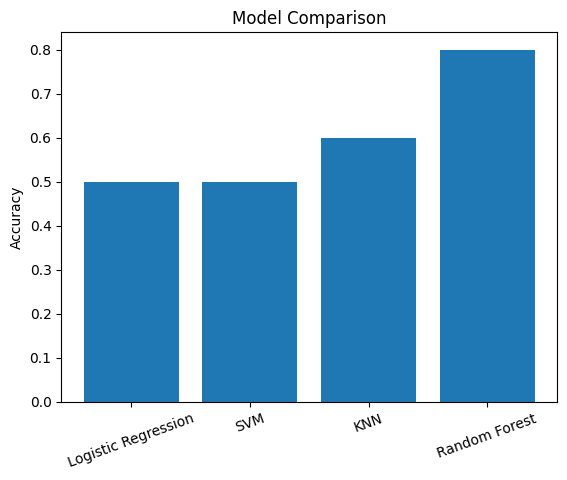

In [10]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

### Conclusion

Among the evaluated models, Random Forest achieved the highest accuracy on the dataset. 
This suggests that nonlinear models may capture relationships in EEG band power features 
more effectively than linear models.

However, due to the small dataset size, accuracy fluctuations were observed across 
cross-validation folds, and results may not generalize well to larger datasets.